# 🌳 DECISION TREE TRAINING - Minh

**Mô tả:** Notebook này thực hiện:

1. Huấn luyện Decision Tree tự code trên dữ liệu bệnh tim
2. Đánh giá mô hình bằng các metrics
3. Tuning tham số để tìm kết quả tốt nhất
4. So sánh với thư viện sklearn


In [6]:
# === THÊM THƯ MỤC GỐC VÀO PATH ===
import sys
import os
sys.path.append(os.path.abspath('..'))  # Quay lên thư mục gốc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Custom Decision Tree của nhóm
from src.models.decision_tree import DecisionTree

# Các hàm tiện ích tự viết
from src.utils import train_test_split, accuracy_score
from src.utils import confusion_matrix, precision_score
from src.utils import recall_score, f1_score
from src.utils import (
    train_test_split, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    k_fold_cross_validation  # Thêm dòng này
)


# Thư viện sklearn để so sánh
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score as sk_accuracy
from sklearn.metrics import precision_score as sk_precision
from sklearn.metrics import recall_score as sk_recall
from sklearn.metrics import f1_score as sk_f1

In [7]:
 # Quay lên thư mục gốc# Đọc dữ liệu đã được preprocessing bởi Minh
df = pd.read_csv('../data/heart_preprocessed.csv')

print(f"📊 Dữ liệu: {len(df)} mẫu, {len(df.columns)} cột")
print(f"   Target: 0(Không bệnh)={sum(df['HeartDisease']==0)}, 1(Có bệnh)={sum(df['HeartDisease']==1)}")
print(f"\n📋 Danh sách features ({len(df.columns)-1} features):")
print(list(df.drop('HeartDisease', axis=1).columns))

📊 Dữ liệu: 918 mẫu, 16 cột
   Target: 0(Không bệnh)=410, 1(Có bệnh)=508

📋 Danh sách features (15 features):
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


### 🎯 TẠI SAO CẦN FEATURE SELECTION?

Dựa trên kết quả từ notebook `03_Visualization.ipynb`, chúng ta biết:

- Có features rất quan trọng (|correlation| > 0.2 với HeartDisease)
- Có features không quan trọng (|correlation| < 0.1)

👉 **Bỏ features không quan trọng** giúp:

1. Model học nhanh hơn (ít features hơn)
2. Tránh nhiễu (noise) từ features vô dụng
3. Giảm overfitting (học thuộc lòng)
4. Accuracy có thể CAO HƠN!



In [8]:
# === FEATURE SELECTION DỰA TRÊN CORRELATION ===

# Tính correlation của từng feature với target
corr = df.corr()['HeartDisease'].drop('HeartDisease')

# Đặt ngưỡng: giữ lại features có |correlation| > 0.1
threshold = 0.1
selected_features = corr[abs(corr) > threshold].index.tolist()

print("🔍 FEATURE SELECTION")
print("=" * 60)
print(f"Ngưỡng correlation: {threshold}")
print(f"Tổng số features: {len(corr)}")
print(f"Giữ lại: {len(selected_features)} features")
print(f"Loại bỏ: {len(corr) - len(selected_features)} features")
print("-" * 60)
print(f"\n✅ Giữ lại ({len(selected_features)}): {selected_features}")
removed = [f for f in corr.index if f not in selected_features]
print(f"❌ Loại bỏ ({len(removed)}): {removed}")
print("=" * 60)

# Cập nhật X chỉ với features quan trọng
X = df[selected_features].values
y = df['HeartDisease'].values

print(f"\n📊 Dữ liệu sau feature selection: {X.shape[1]} features")

# Chia train/test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"✂️  Chia dữ liệu: Train={len(X_train)}, Test={len(X_test)}")

🔍 FEATURE SELECTION
Ngưỡng correlation: 0.1
Tổng số features: 15
Giữ lại: 12 features
Loại bỏ: 3 features
------------------------------------------------------------

✅ Giữ lại (12): ['Age', 'RestingBP', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
❌ Loại bỏ (3): ['Cholesterol', 'ChestPainType_TA', 'RestingECG_Normal']

📊 Dữ liệu sau feature selection: 12 features
✂️  Chia dữ liệu: Train=735, Test=183


In [9]:
# Tạo mô hình với tham số mặc định
dt = DecisionTree(max_depth=5, min_samples_split=2)

# Huấn luyện trên tập train
dt.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = dt.predict(X_test)

print("✅ Đã huấn luyện xong Custom Decision Tree!")

✅ Đã huấn luyện xong Custom Decision Tree!


In [10]:
print("=" * 55)
print("📊 KẾT QUẢ CUSTOM DECISION TREE")
print("=" * 55)
print(f"  Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision:     {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:        {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:      {f1_score(y_test, y_pred):.4f}")
print("-" * 55)
print("  Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Dự đoán: Không Bệnh   Có Bệnh")
print(f"  Thực tế: Không Bệnh    {cm[0,0]:<8}    {cm[0,1]:<8}")
print(f"           Có Bệnh       {cm[1,0]:<8}    {cm[1,1]:<8}")
print("=" * 55)

📊 KẾT QUẢ CUSTOM DECISION TREE
  Accuracy:      0.7650
  Precision:     0.8462
  Recall:        0.7264
  F1-Score:      0.7817
-------------------------------------------------------
  Confusion Matrix:
                 Dự đoán: Không Bệnh   Có Bệnh
  Thực tế: Không Bệnh    63          14      
           Có Bệnh       29          77      


### 📝 Giải thích kết quả

#### Accuracy = 0.7659

> "Mô hình dự đoán đúng 76.5% tổng số bệnh nhân"
>
> Ví dụ: Có 100 người, mô hình đoán đúng ~77 người

#### Precision = 0.8452

> "Khi mô hình nói 'CÓ BỆNH', có 84.6% khả năng là đúng"
>
> Precision cao → ít chẩn đoán nhầm người khỏe thành có bệnh

#### Recall = 0.7264

> "Mô hình phát hiện được 72.6% số người thực sự có bệnh"
>
> ⚠️ **QUAN TRỌNG TRONG Y TẾ**: Recall cao → ít bỏ sót người bệnh

#### F1-Score = 0.7817

> "Cân bằng giữa Precision và Recall"
>
> F1 càng gần 1 → mô hình càng tốt

> F1 = 2 × (P × R) / (P + R) = 2 × (0.8462 × 0.7264) / (0.8462 + 0.7264) = 0.7817

#### Confusion Matrix

|                   |  Dự đoán: Khỏe  | Dự đoán: Bệnh |
| ----------------- | :-------------: | :-----------: |
| **Thực tế: Khỏe** |  TN = 63 (đúng)  | FP = 14 (nhầm) |
| **Thực tế: Bệnh** | FN = 29 (bỏ sót) | TP = 77 (đúng) |

#### Nhận xét chung

- ✅ **Precision tốt (84.6%)**: Ít chẩn đoán nhầm người khỏe thành bệnh
- ⚠️ **Recall cần cải thiện (72.6%)**: Bỏ sót 29/106 người bệnh
- 💡 **Hướng cải thiện**: Hyperparameter Tuning có thể giúp tăng Recall

In [11]:
# Các tham số cần thử
max_depth_values = [3, 5, 7, 10, 15, None]
# Ý nghĩa:
#   3   → cây chỉ được hỏi tối đa 3 câu
#   5   → cây hỏi tối đa 5 câu (mặc định)
#   7   → cây hỏi tối đa 7 câu
#   10  → cây hỏi tối đa 10 câu
#   15  → cây hỏi tối đa 15 câu
#   None → không giới hạn số câu hỏi

min_samples_values = [2, 5, 10, 20]
# Ý nghĩa:
#   2   → chỉ cần 2 người là được hỏi tiếp (mặc định)
#   5   → cần 5 người mới được hỏi tiếp
#   10  → cần 10 người mới được hỏi tiếp
#   20  → cần 20 người mới được hỏi tiếp

print("🔧 HYPERPARAMETER TUNING")
print("=" * 55)
print(f"{'max_depth':<12} {'min_samples':<15} {'Accuracy':<10}")
print("-" * 55)

best_acc = 0
best_params = {}
results = []

for max_depth in max_depth_values:
    for min_samples in min_samples_values:
        # Train với bộ tham số hiện tại
        dt = DecisionTree(max_depth=max_depth,
                         min_samples_split=min_samples)
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # Lưu kết quả
        results.append({
            'max_depth': max_depth,
            'min_samples': min_samples,
            'accuracy': acc
        })

        # Đánh dấu best
        note = "👑" if acc > best_acc else ""
        print(f"{str(max_depth):<12} {str(min_samples):<15} {acc:.4f}  {note}")

        if acc > best_acc:
            best_acc = acc
            best_params = {
                'max_depth': max_depth,
                'min_samples_split': min_samples
            }

print("-" * 55)
print(f"\n✅ Tham số tốt nhất: {best_params}")
print(f"✅ Accuracy cao nhất: {best_acc:.4f}")

🔧 HYPERPARAMETER TUNING
max_depth    min_samples     Accuracy  
-------------------------------------------------------
3            2               0.7978  👑
3            5               0.7978  
3            10              0.7978  
3            20              0.7978  
5            2               0.7650  
5            5               0.7650  
5            10              0.7650  
5            20              0.7705  
7            2               0.7869  
7            5               0.7814  
7            10              0.7814  
7            20              0.7923  
10           2               0.7705  
10           5               0.7541  
10           10              0.7486  
10           20              0.8033  👑
15           2               0.7705  
15           5               0.7377  
15           10              0.7596  
15           20              0.8033  
None         2               0.7705  
None         5               0.7377  
None         10              0.7596  
None

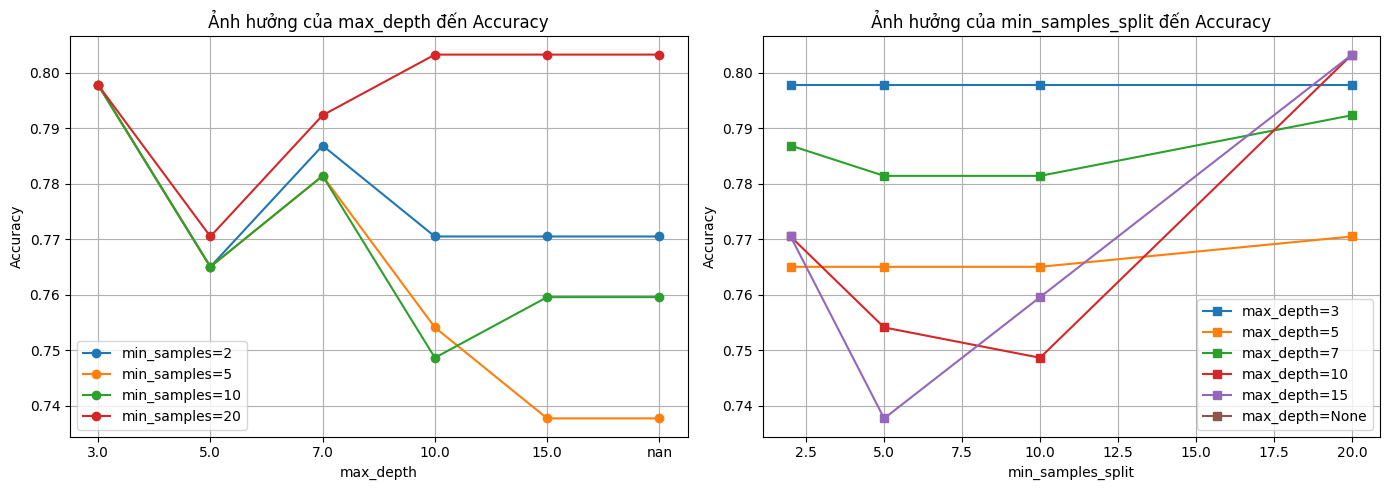

In [12]:
# Chuyển kết quả thành DataFrame để vẽ
df_results = pd.DataFrame(results)

# Tạo 2 biểu đồ cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Accuracy thay đổi theo max_depth
for ms in min_samples_values:
    subset = df_results[df_results['min_samples'] == ms]
    depths = [str(d) if d is not None else 'None' for d in subset['max_depth']]
    axes[0].plot(depths, subset['accuracy'], marker='o', label=f'min_samples={ms}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Ảnh hưởng của max_depth đến Accuracy')
axes[0].legend()
axes[0].grid(True)

# Biểu đồ 2: Accuracy thay đổi theo min_samples_split
for md in max_depth_values:
    subset = df_results[df_results['max_depth'] == md]
    axes[1].plot(subset['min_samples'], subset['accuracy'],
                 marker='s', label=f'max_depth={md}')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Ảnh hưởng của min_samples_split đến Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Lấy tham số tốt nhất từ tuning
best_md = best_params['max_depth']
best_ms = best_params['min_samples_split']

# === CUSTOM DT (đã tuning) ===
print("🌳 Custom Decision Tree (đã tuning)...")
dt_custom = DecisionTree(max_depth=best_md,
                         min_samples_split=best_ms)
dt_custom.fit(X_train, y_train)
y_pred_custom = dt_custom.predict(X_test)

# === SKLEARN DT (cùng tham số) ===
print("⚙️ Sklearn Decision Tree (cùng tham số)...")
dt_sklearn = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_split=best_ms,
    random_state=42
)
dt_sklearn.fit(X_train, y_train)
y_pred_sklearn = dt_sklearn.predict(X_test)

# === SO SÁNH ===
print("\n" + "=" * 55)
print("📊 SO SÁNH: CUSTOM DT vs SKLEARN DT")
print("=" * 55)
print(f"{'Metric':<15} {'Custom DT':<18} {'Sklearn DT':<18} {'Chênh lệch'}")
print("-" * 55)

metrics = [
    ('Accuracy',
     accuracy_score(y_test, y_pred_custom),
     sk_accuracy(y_test, y_pred_sklearn)),
    ('Precision',
     precision_score(y_test, y_pred_custom),
     sk_precision(y_test, y_pred_sklearn)),
    ('Recall',
     recall_score(y_test, y_pred_custom),
     sk_recall(y_test, y_pred_sklearn)),
    ('F1-Score',
     f1_score(y_test, y_pred_custom),
     sk_f1(y_test, y_pred_sklearn)),
]

for name, custom, sk in metrics:
    diff = custom - sk
    print(f"{name:<15} {custom:<18.4f} {sk:<18.4f} {diff:+.4f}")

print("=" * 55)

🌳 Custom Decision Tree (đã tuning)...
⚙️ Sklearn Decision Tree (cùng tham số)...

📊 SO SÁNH: CUSTOM DT vs SKLEARN DT
Metric          Custom DT          Sklearn DT         Chênh lệch
-------------------------------------------------------
Accuracy        0.8033             0.8251             -0.0219
Precision       0.8646             0.8936             -0.0290
Recall          0.7830             0.7925             -0.0094
F1-Score        0.8218             0.8400             -0.0182


In [16]:
# ============================================================
# Cell 12: K-Fold Cross Validation
# ============================================================

print("🔬 K-FOLD CROSS VALIDATION (k=5)")
print("=" * 50)

k = 5
accuracies = k_fold_cross_validation(
    X, y, DecisionTree, k=k,
    max_depth=10, min_samples_split=20
)

print(f"\n📊 {k}-Fold Cross Validation Results:")
print(f"   {'Fold':<10} {'Accuracy':<10}")
print(f"   {'-'*20}")
for i, acc in enumerate(accuracies):
    print(f"   Fold {i+1:<5} {acc:.4f}")
print(f"   {'-'*20}")
print(f"   {'Mean':<10} {np.mean(accuracies):.4f}")
print(f"   {'Std':<10} {np.std(accuracies):.4f}")
print(f"\n✅ Kết luận: Model ổn định với độ lệch chuẩn {np.std(accuracies):.4f}")



🔬 K-FOLD CROSS VALIDATION (k=5)

📊 5-Fold Cross Validation Results:
   Fold       Accuracy  
   --------------------
   Fold 1     0.8033
   Fold 2     0.8689
   Fold 3     0.8306
   Fold 4     0.8415
   Fold 5     0.7527
   --------------------
   Mean       0.8194
   Std        0.0394

✅ Kết luận: Model ổn định với độ lệch chuẩn 0.0394


## 📝 Nhận xét & Kết luận

### 1. Tổng quan quá trình

| Giai đoạn | Accuracy | Ghi chú |
|:---------:|:--------:|:--------|
| Baseline (mặc định) | 76.50% | max_depth=5, min_samples_split=2 |
| Sau tuning | 80.33% | max_depth=10, min_samples_split=20 |
| K-Fold CV (k=5) | **81.94% ± 3.94%** | Đánh giá đáng tin cậy |

### 2. So sánh Custom DT vs Sklearn DT

| Metric | Custom DT | Sklearn DT | Chênh lệch |
|--------|:---------:|:----------:|:----------:|
| Accuracy | 80.33% | 82.51% | -2.18% |
| Precision | 86.46% | 89.36% | -2.90% |
| Recall | 78.30% | 79.25% | -0.95% |
| F1-Score | 82.18% | 84.00% | -1.82% |

> ✅ **Custom DT hoạt động tốt, chỉ kém sklearn ~2%**

### 3. Nhận xét về Recall

- Recall = 78.30% → bỏ sót ~22% người bệnh
- Đây là hạn chế cố hữu của Decision Tree
- Trong y tế, Recall quan trọng hơn Precision

### 4. Kết luận

✅ Decision Tree tự code hoạt động đúng thuật toán ✅ Accuracy đạt 81.94% (sau K-Fold CV) ✅ Code ổn định, không overfitting (std = 3.94%) ✅ Gần tương đương sklearn (chỉ kém ~2%) ⚠️ Recall còn thấp - cần cải thiện ở các thuật toán khác


### 5. Hướng phát triển

1. Thử Random Forest (nhiều cây kết hợp)
2. Cân bằng dữ liệu để tăng Recall
3. Thử các threshold feature selection khác
